# <font color='00aaff'> **Processo Seletivo Pi Júnior 2025/1** </font>

## **Trabalho Prático - Python**

Olá, trainee! Parabéns por chegar até aqui. Nesse notebook será realizado o desafio envolvendo todo o conteúdo de python que vocês aprenderam.

Primeiramente, recomendamos que assistam a todas as aulas de python disponibilizadas, além de dar uma olhada nos Notebook de cada uma.

_Atenção: A organização e legibilidade do seu código serão avaliadas, logo, certifique-se de seguir as boas práticas da programação._


## **Web Scraping**


Nesta seção, iremos coletar os dados do site <a href='https://books.toscrape.com'>**books to scrape**</a>. Nele podemos encontrar diversos livros diferentes, sendo que cada livro possui uma página separada com informações detalhadas da obra escolhida.


### **Exercício**


**O seu desafio será iterar entre as 10 primeiras páginas do site, pegar os links de todos os livros de cada página e, para cada um, coletar os seguintes dados:**

- `Título`

- `Descrição`

- `Categoria`

- `Preço`

- `Avaliação`

_Obs: Os dados coletados serão usados na próxima seção, portanto, garanta que estejam armazenados, seja em uma lista, dicionário ou qualquer outra estrutura de dados que considerar adequada._


Url do site: https://books.toscrape.com


In [58]:
from seleniumbase import SB
from urllib.parse import urljoin
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

URL = "https://books.toscrape.com/"

In [10]:
def log(message):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {message}")

## **Ciência de Dados**


Agora que você já coletou os dados do site <a href='https://books.toscrape.com'>**books to scrape**</a>, vamos explorar e manipular essa base de dados para obter insights sobre os livros.


### **Exercícios**


#### **1: Criação e Limpeza do DataFrame**

Transforme os dados coletados da seção anterior em um **DataFrame do Pandas** e realize os seguintes procedimentos de limpeza:

- Crie um DataFrame a partir dos dados coletados, garantindo que as colunas representem corretamente as informações: `Título`, `Descrição`, `Categoria`, `Preço`, `Avaliação`.
- Remova ou trate quaisquer dados ausentes (se houver).
- Converta a coluna de **Avaliação** para o tipo inteiro.
- Converta a coluna de **Preço** para o tipo numérico (float).
- Verifique se há duplicatas no DataFrame e remova-as, se necessário.


In [30]:
books_data = []

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

with SB() as sb:

    # criando um loop aqui para acessar cada uma das 10 páginas
    for page in range(1, 11): 

        log(f"Coletando página {page}")

        sb.open(f"{URL}catalogue/page-{page}.html")

        sb.wait_for_element_visible(
            "article.product_pod",
            timeout=10
        )

        # div principal que guarda uma lista dos livros
        books = sb.find_elements(
            "article.product_pod h3 a",
        )

        # lista que vai guardar todos os links para livros na página
        links = []
        for book in books:

            # cada livro tem o link para sua página específica no <a\>
            relative_link = book.get_attribute(
                "href"
            )

            # juntando o link original com a nova url
            full_link = urljoin(
                URL,
                relative_link
            )

            links.append(full_link)

        log(f"{len(links)} achados!")

        # circulando por cada link obtido
        for link in links:
            log(f"Acessando link: {link}")

            sb.open(link)
            sb.wait_for_element_visible(
                "div.product_main",
                timeout=10
            )

            log("Coletando informação do livro...")
            title = sb.get_text(
                "div.product_main h1"
            )
            try:
                description = sb.get_text(
                    "#product_description + p"
                )
            except:
                description = "Sem descrição"

            category = sb.find_elements(
                "ul.breadcrumb li a"
            )[-1].text

            price = sb.get_text(
                "p.price_color"
            )

            rating_class = sb.find_element(
                "p.star-rating"
            ).get_attribute("class")

            rating_text = rating_class.replace(
                "star-rating",
                ""
            ).strip()

            # transfomando as str de avaliação em números para comparação
            rating = rating_map[rating_text]

            log("Dados extraídos com sucesso! Salvando na lista")
            book_data = {
                "Título": title,
                "Descrição": description,
                "Categoria": category,
                "Preço (£)": float(price[1:]), # transformando o preço em float para facilitar processos
                "Avaliação": rating
            }
            print() # pulando uma linha para organizar
            books_data.append(book_data)

# transformando o dict com dados em DataFrame
df_books = pd.DataFrame(books_data)

print(f"\nTotal de livros coletados: {len(books_data)}")

[17:45:19] Coletando página 1
[17:45:21] 20 achados!
[17:45:21] Acessando link: https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html
[17:45:21] Coletando informação do livro...
[17:45:22] Dados extraídos com sucesso! Salvando na lista

[17:45:22] Acessando link: https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html
[17:45:22] Coletando informação do livro...
[17:45:22] Dados extraídos com sucesso! Salvando na lista

[17:45:22] Acessando link: https://books.toscrape.com/catalogue/soumission_998/index.html
[17:45:23] Coletando informação do livro...
[17:45:23] Dados extraídos com sucesso! Salvando na lista

[17:45:23] Acessando link: https://books.toscrape.com/catalogue/sharp-objects_997/index.html
[17:45:24] Coletando informação do livro...
[17:45:25] Dados extraídos com sucesso! Salvando na lista

[17:45:25] Acessando link: https://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html
[17:45:25] Coletando informação do li

In [31]:
df_books

,Título,Descrição,Categoria,Preço (£),Avaliação
0,A Light in the Attic,It's hard to imagine a world without A Light i...,Poetry,51.77,3
1,Tipping the Velvet,"""Erotic and absorbing...Written with starling ...",Historical Fiction,53.74,1
2,Soumission,"Dans une France assez proche de la nôtre, un h...",Fiction,50.10,1
3,Sharp Objects,"WICKED above her hipbone, GIRL across her hear...",Mystery,47.82,4
4,Sapiens: A Brief History of Humankind,From a renowned historian comes a groundbreaki...,History,54.23,5
...,...,...,...,...,...
195,Eureka Trivia 6.0,Eureka Trivia 6.0 is a great trivia book for a...,Default,54.59,4
196,Drive: The Surprising Truth About What Motivat...,Forget everything you thought you knew about h...,Default,34.95,4
197,Done Rubbed Out (Reightman & Bailey #1),In this first book of the Reightman & Bailey S...,Default,37.72,5
198,Doing It Over (Most Likely To #1),"Voted Most Likely to Succeed, Melanie Bartlett...",Romance,35.61,3


#### **2: Análise de Categoria**

Quantos livros pertencem a cada **categoria**?

- **Objetivo**: Criar uma visualização gráfica para mostrar a quantidade de livros por categoria.

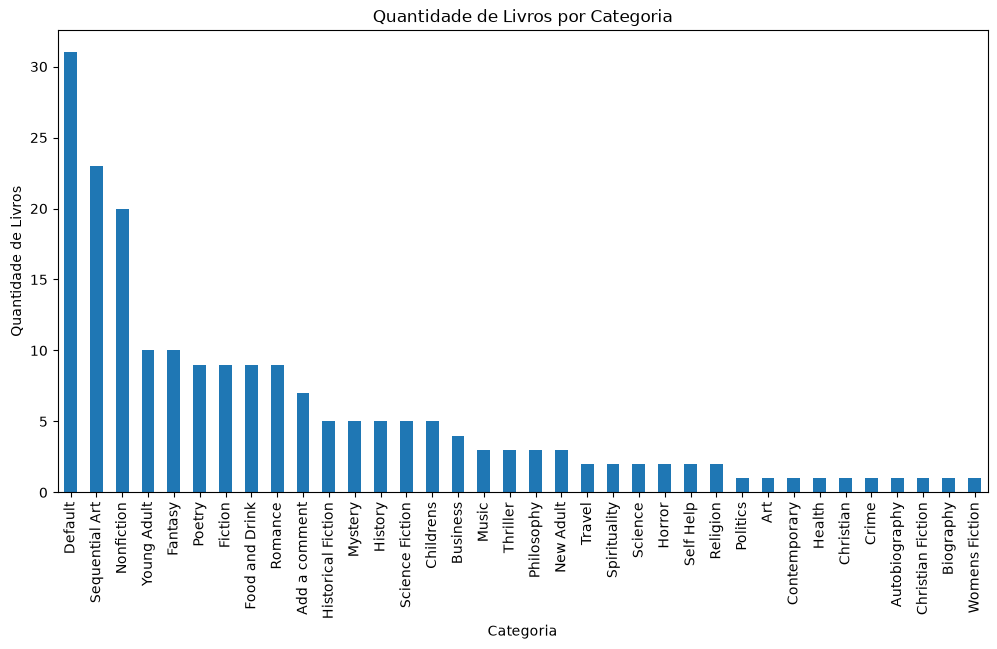

In [32]:
categoria_counts = (
    df_books['Categoria']
    .value_counts()
)

plt.figure(figsize=(12,6))

categoria_counts.plot(
    kind='bar'
)

plt.title('Quantidade de Livros por Categoria')

plt.xlabel('Categoria')
plt.ylabel('Quantidade de Livros')

plt.xticks(rotation=90)

plt.show()

#### **3: Análise de Preços**

Responda às seguintes perguntas sobre os preços dos livros:

- Qual é o livro mais caro? E o mais barato?
- Qual é o **preço médio** dos livros?


In [33]:
livro_mais_caro = df_books.loc[
    df_books['Preço (£)'].idxmax()
]

livro_mais_barato = df_books.loc[
    df_books['Preço (£)'].idxmin()
]

preco_medio = df_books['Preço (£)'].mean()

print("Livro mais caro:")
print(
    livro_mais_caro[
        ['Título', 'Preço (£)']
    ]
)

print("\nLivro mais barato:")
print(
    livro_mais_barato[
        ['Título', 'Preço (£)']
    ]
)

print(
    f"\nPreço médio dos livros: £{preco_medio:.2f}"
)

Livro mais caro:
Título       Thomas Jefferson and the Tripoli Pirates: The ...
Preço (£)                                                59.64
Name: 133, dtype: object

Livro mais barato:
Título       Patience
Preço (£)       10.16
Name: 84, dtype: object

Preço médio dos livros: £34.80


#### **4: Relação entre Avaliação e Preço**

Existe alguma relação entre o **preço** dos livros e suas **avaliações**?

- **Objetivo**: Crie um gráfico de dispersão para visualizar a relação entre as duas variáveis e comente sobre o padrão observado.


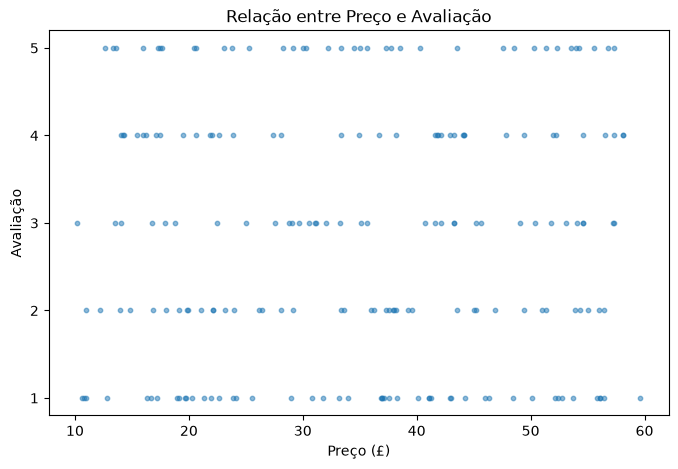

In [72]:
plt.figure(figsize=(8,5))

plt.scatter(df_books['Preço (£)'], df_books['Avaliação'], s=10, alpha=0.5)

plt.xlabel('Preço (£)')
plt.ylabel('Avaliação')
plt.title('Relação entre Preço e Avaliação')

plt.yticks([1, 2, 3, 4, 5])

plt.show()

#### **5: Top 10 Livros**

Liste os **mais bem avaliados** e seus respectivos preços.

- **Objetivo**: Exibir os 10 livros com as maiores avaliações.


In [ ]:
top_10 = (
    df_books
    .sort_values(by='Avaliação', ascending=False)
    .head(10)
    [['Título', 'Avaliação', 'Preço (£)']]
    .reset_index(drop=True)
)

top_10.index = top_10.index + 1 # corrigindo index para ficar com 1-10

print(top_10)

                                               Título  Avaliação  Preço (£)
1               Sapiens: A Brief History of Humankind          5      54.23
2   Worlds Elsewhere: Journeys Around Shakespeare’...          5      40.30
3   The Four Agreements: A Practical Guide to Pers...          5      17.66
4                                   The Elephant Tree          5      23.82
5                          Chase Me (Paris Nights #2)          5      25.27
6                                         Set Me Free          5      17.46
7                           Rip it Up and Start Again          5      35.02
8   Scott Pilgrim's Precious Little Life (Scott Pi...          5      52.29
9                                      Sophie's World          5      15.94
10                       We Love You, Charlie Freeman          5      50.27


#### **6: Comparação de Preços por Categoria**

Qual é a **categoria mais cara** em termos de preço médio dos livros?

- **Objetivo**: Agrupar os livros por categoria e calcular o preço médio de cada categoria, e então determinar a categoria com o maior preço médio.


In [41]:
(
    df_books.groupby("Categoria")["Preço (£)"]
    .mean()
    .sort_values(ascending=False) # ajustando para ordenar decrescente
    .head(1)
)

Categoria
Womens Fiction    57.36
Name: Preço (£), dtype: float64

#### **7: Distribuição de Avaliações**

Visualize a distribuição das **avaliações** dos livros no site.

- **Objetivo**: Criar um histograma que mostre a frequência de cada nível de avaliação (1 a 5 estrelas).


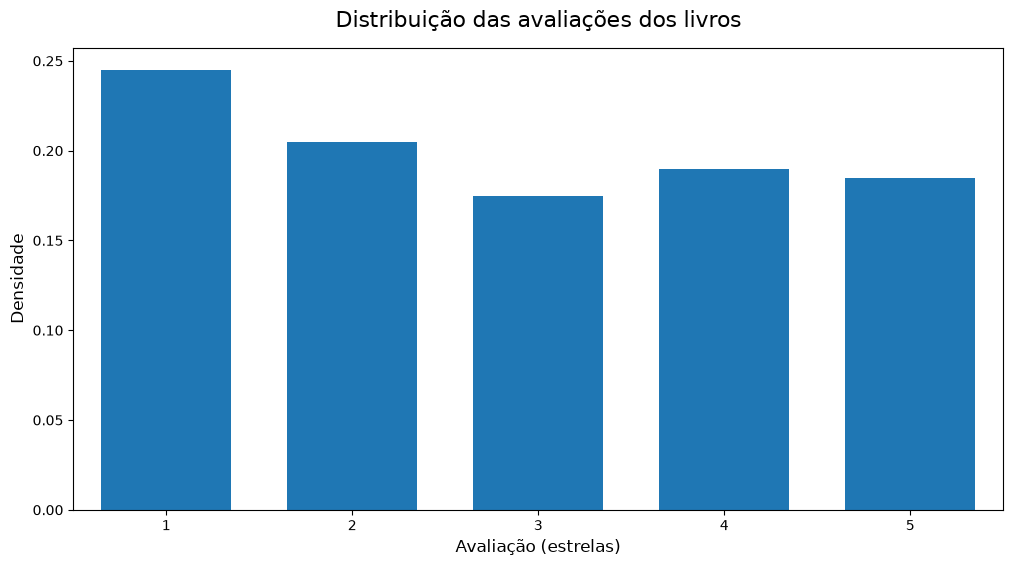

In [63]:
plt.figure(figsize=(12, 6))

plt.hist(
    df_books["Avaliação"],
    bins=np.arange(0.5, 6.5, 1),
    density=True,
    rwidth=0.7,
)

plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Avaliação (estrelas)", fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.title(
    "Distribuição das avaliações dos livros",
    fontsize=16,
    pad=15
)


plt.xlim(0.5, 5.5)
plt.show()

#### **8: Top 5 Categorias Mais Populares**

Quais são as **5 categorias** com o maior número de livros disponíveis?

- **Objetivo**: Contar o número de livros em cada categoria e listar as 5 categorias mais populares.


In [64]:
top5 = (
    df_books["Categoria"]
    .value_counts()
    .head(5)
)

print(top5)

Categoria
Default           31
Sequential Art    23
Nonfiction        20
Young Adult       10
Fantasy           10
Name: count, dtype: int64


#### **9: Livro com Melhor Custo-Benefício**

Defina o livro com **melhor custo-benefício** como aquele com a maior avaliação em relação ao preço.

- **Objetivo**: Criar uma nova coluna que calcule a relação entre **avaliação** e **preço** e encontrar o livro com a maior relação.


In [65]:
df_books["Custo-Beneficio"] = (
    df_books["Avaliação"] / df_books["Preço (£)"]
)

melhor = df_books.loc[
    df_books["Custo-Beneficio"].idxmax()
]

print(melhor[[
    "Título",
    "Avaliação",
    "Preço (£)",
    "Custo-Beneficio"
]])

Título             The Third Wave: An Entrepreneur’s Vision of th...
Avaliação                                                          5
Preço (£)                                                      12.61
Custo-Beneficio                                             0.396511
Name: 138, dtype: object


#### **10: Livros com Descrição mais Longa**

Encontre os **3 livros com a descrição mais longa**.

- **Objetivo**: Criar uma nova coluna com o comprimento das descrições e ordenar os livros com base nessa coluna.


In [ ]:
# criando nova coluna com tamanho de cada descrição
df_books["Tam_Descricao"] = (
    df_books["Descrição"]
    .str.len()
)

top3_descricoes = (
    df_books
    .sort_values(
        by="Tam_Descricao",
        ascending=False
    )
    .head(3)
)

print(
    top3_descricoes[
        ["Título", "Tam_Descricao"]
    ]
)

                                                Título  Tam_Descricao
55         The Torch Is Passed: A Harding Family Story           4374
146  The Omnivore's Dilemma: A Natural History of F...           3707
7    The Coming Woman: A Novel Based on the Life of...           3411


#### **Extra: Criação de Novas Visualizações**

Agora que você já explorou os dados coletados, crie **mais visualizações** que você considere relevantes e interessantes. Use diferentes tipos de gráficos para apresentar insights novos ou complementares sobre os livros.

Sinta-se à vontade para explorar outros tipos de gráficos que ajudem a destacar padrões ou tendências nos dados.


Média de avaliação por categoria

<Axes: ylabel='Categoria'>

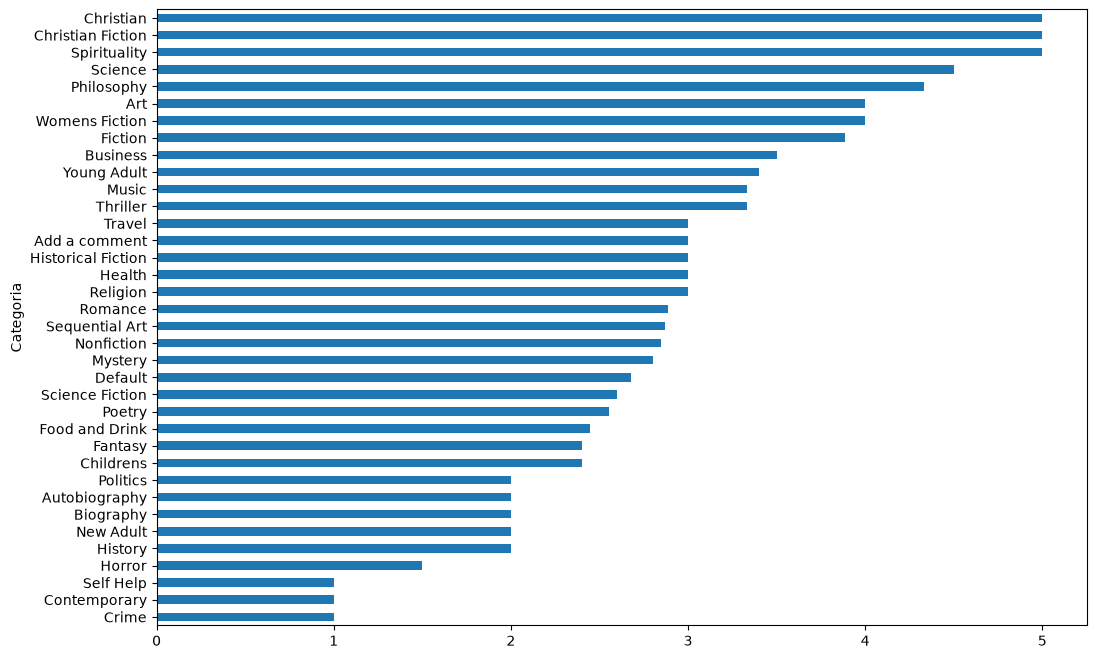

In [73]:
(
    df_books.groupby("Categoria")["Avaliação"]
    .mean()
    .sort_values()
    .plot(
        kind="barh",
        figsize=(12,8)
    )
)